In [ ]:
os.environ["NCCL_DEBUG"]="INFO"

In [1]:
%%parakernel restart

Magic Success on %%parakernel restart

In [1]:
%%parakernel display --global_rank 0,10

Magic Success on %%parakernel display --global_rank 0,10

In [2]:
import os
local_rank = int(os.environ.get("LOCAL_RANK", 0))
os.environ["MASTER_ADDR"] = "10.60.0.51"
os.environ["MASTER_PORT"] = "12399"
os.environ["WORLD_SIZE"] = str(
    int(os.environ["NODE_WORLD_SIZE"]) * 8
    if int(os.environ["LOCAL_WORLD_SIZE"]) == 8
    else os.environ["LOCAL_WORLD_SIZE"]
)
os.environ["HF_HOME"] = "/data/hf" 

In [3]:
import math
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.distributed as dist
from torch.distributed._tensor import DeviceMesh, Replicate, Shard, distribute_tensor

from rl_comm import (
    gather_broadcast_communicate,
    get_p2p_map,
    get_shard_tensor_shape,
    p2p_communicate,
)

In [4]:
device = "cuda"
rank = int(os.environ["RANK"])
local_rank = int(os.environ["LOCAL_RANK"])
world_size = int(os.environ["WORLD_SIZE"])

if device == "cuda":
    dist.init_process_group(backend="nccl")
    torch.cuda.set_device(local_rank)
else:
    dist.init_process_group(backend="gloo")

In [5]:
# BENCHMARKING PARAMETERS
warmup_iter = 20
profile_iter = 50
tensor_shapes = [
    (512, 512),
    (1024, 1024),
    (2048, 2048),
    (4096, 4096),
    (8192, 8192),
    (12288, 12888),
    (16384, 16384),
    (20480, 20480),
    (24576, 24576),
    (28672, 28672),
    (32768, 32768),
]

# 16卡的mesh组合 (source + target = 16, 每个维度是2的幂次: 1,2,4,8)
# 混合不同的source和target组合
mesh_combinations = [
    # 8+8=16的不同组合
    ((1, 1, 1, 8), (2, 2, 2, 1)),  # 线性 vs 紧凑
    ((1, 1, 2, 4), (1, 2, 2, 2)),  # 中等 vs 平衡
    ((1, 1, 4, 2), (4, 2, 1, 1)),  # 宽 vs 高
    ((1, 2, 1, 4), (1, 4, 2, 1)),  # 不同维度分布
    ((1, 2, 2, 2), (2, 1, 4, 1)),  # 平衡 vs 长条
    ((1, 2, 4, 1), (8, 1, 1, 1)),  # 扁平 vs 线性
    ((1, 4, 1, 2), (1, 1, 8, 1)),  # 中等 vs 单维
    ((1, 4, 2, 1), (1, 8, 1, 1)),  # 宽 vs 深
    ((1, 8, 1, 1), (2, 2, 1, 2)),  # 单维 vs 分布
    ((2, 1, 1, 4), (1, 1, 2, 4)),  # 长 vs 宽
    ((2, 1, 2, 2), (1, 2, 1, 4)),  # 方形 vs 线性
    ((2, 1, 4, 1), (4, 1, 2, 1)),  # 条状 vs 条状
    ((2, 2, 1, 2), (1, 4, 1, 2)),  # 原始 vs 变形
    ((2, 2, 2, 1), (1, 1, 4, 2)),  # 立方 vs 扁平
    ((2, 4, 1, 1), (1, 2, 4, 1)),  # 矩形不同方向
    ((4, 1, 1, 2), (2, 1, 1, 4)),  # 对称变换
    ((4, 1, 2, 1), (1, 1, 1, 8)),  # 分布 vs 线性
    ((4, 2, 1, 1), (1, 1, 2, 4)),  # 紧凑 vs 分布
    ((8, 1, 1, 1), (1, 2, 2, 2)),  # 线性 vs 立方
]

print(f"总共有 {len(mesh_combinations)} 个不同的16卡mesh组合")

source_specs = [Replicate(), Shard(0), Replicate(), Shard(1)]
target_specs = [Replicate(), Replicate(), Shard(0), Shard(1)]

总共有 19 个不同的16卡mesh组合
总共有 19 个不同的16卡mesh组合


开始批量测试所有mesh组合...
总共有 19 个mesh组合需要测试
\n================================================================================
测试第 1/19 个mesh组合:
源mesh: (1, 1, 1, 8) -> 目标mesh: (2, 2, 2, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡
开始批量测试所有mesh组合...
总共有 19 个mesh组合需要测试
\n================================================================================
测试第 1/19 个mesh组合:
源mesh: (1, 1, 1, 8) -> 目标mesh: (2, 2, 2, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once
/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03195258305990137
Forward map: {0: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 1: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 2: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 3: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 4: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 5: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 6: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}, 7: {(0, 0): [8, 10, 12, 14], (1, 0): [9, 11, 13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))], (0, 4): [(4, (0, 0))], (0, 5): [(5, (0, 0))], (0, 6): [(6, (0, 0))], (0, 7): [(7, (0, 0))]}, 9: {(0, 0): [(0, (1, 0))], (0, 1): [(1, (1, 0))], (0, 2): [(2, (1, 0))], (0, 3): [(3, (1, 0))], (0, 4): [(4, (1, 0))], (0, 5): [(5, (1, 0))], (0, 6): [(6, (1, 0))], (0, 7): [(7, (1, 0))]}, 10: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))], (0, 4): [(4, (0, 0)

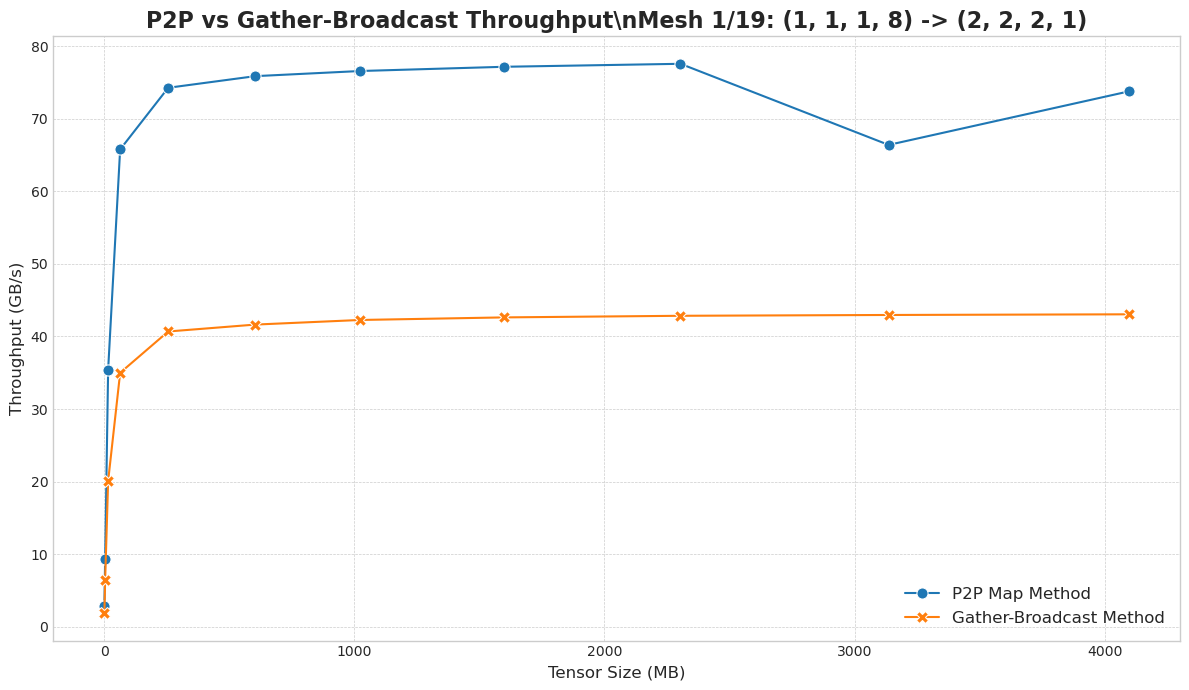

✅ Mesh组合 1 测试完成
Mesh组合 1/19 处理完成
\n================================================================================
测试第 2/19 个mesh组合:
源mesh: (1, 1, 2, 4) -> 目标mesh: (1, 2, 2, 2)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03274185450020013
Forward map: {0: {(0, 0): [8], (1, 0): [10]}, 1: {(0, 0): [8], (1, 0): [10]}, 2: {(0, 0): [9], (1, 0): [11]}, 3: {(0, 0): [9], (1, 0): [11]}, 4: {(0, 0): [12], (1, 0): [14]}, 5: {(0, 0): [12], (1, 0): [14]}, 6: {(0, 0): [13], (1, 0): [15]}, 7: {(0, 0): [13], (1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9: {(0, 0): [(2, (0, 0))], (0, 1): [(3, (0, 0))]}, 10: {(0, 0): [(0, (1, 0))], (0, 1): [(1, (1, 0))]}, 11: {(0, 0): [(2, (1, 0))], (0, 1): [(3, (1, 0))]}, 12: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))]}, 13: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}, 14: {(0, 0): [(4, (1, 0))], (0, 1): [(5, (1, 0))]}, 15: {(0, 0): [(6, (1, 0))], (0, 1): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.03274254771997221
Forward map: {0: {(0, 0): [8], (1, 0): [10]}, 1: {(0, 0): [8], (1, 0): [10]}, 2: {(0, 0): [9], (1, 0): [11]}, 3: {(0, 0): [9], (1, 0): [11]}, 4: {(0, 0): [12], (1, 0): [14]}, 5: {

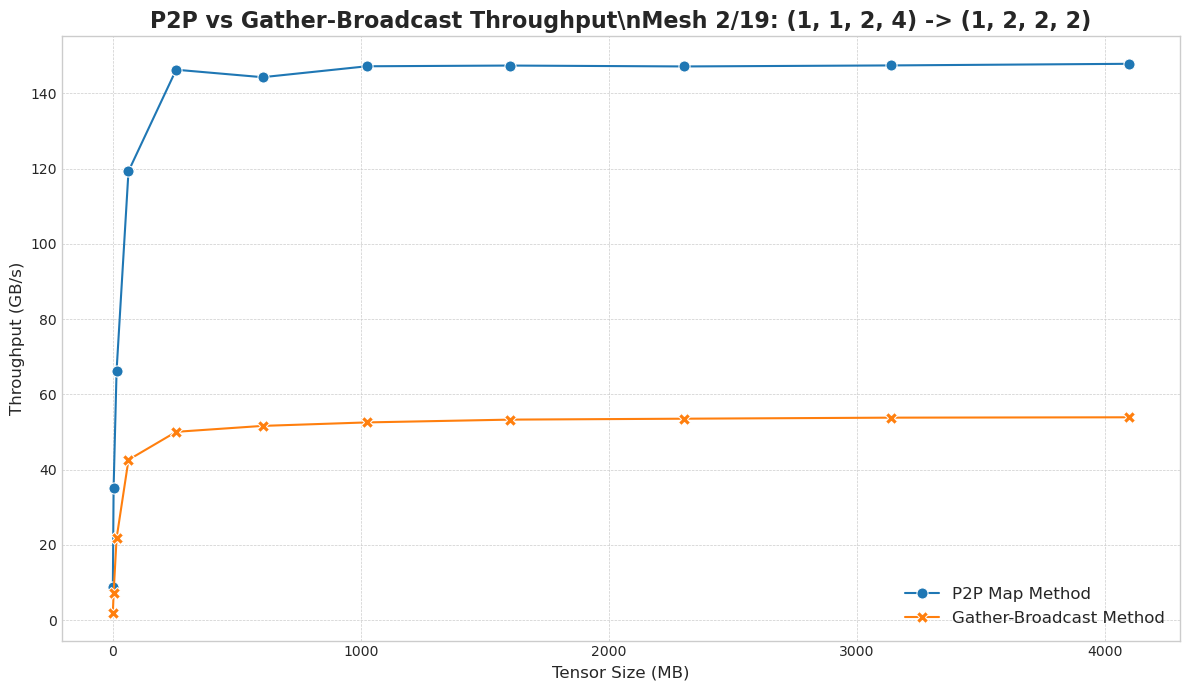

✅ Mesh组合 2 测试完成
Mesh组合 2/19 处理完成
\n================================================================================
测试第 3/19 个mesh组合:
源mesh: (1, 1, 4, 2) -> 目标mesh: (4, 2, 1, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.0296358849198441
Forward map: {0: {(0, 0): [8, 9]}, 1: {(0, 0): [8, 9]}, 2: {(0, 0): [10, 11]}, 3: {(0, 0): [10, 11]}, 4: {(0, 0): [12, 13]}, 5: {(0, 0): [12, 13]}, 6: {(0, 0): [14, 15]}, 7: {(0, 0): [14, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 10: {(0, 0): [(2, (0, 0))], (0, 1): [(3, (0, 0))]}, 11: {(0, 0): [(2, (0, 0))], (0, 1): [(3, (0, 0))]}, 12: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))]}, 13: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))]}, 14: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}, 15: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.02963620345981326
Forward map: {0: {(0, 0): [8, 9]}, 1: {(0, 0): [8, 9]}, 2: {(0, 0): [10, 11]}, 3: {(0, 0): [10, 11]}, 4: {(0, 0): [12, 13]}, 5: {(0, 0): [12, 13]}, 6: {(0, 0): [14, 15]}, 7: {(0, 0): [14, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9

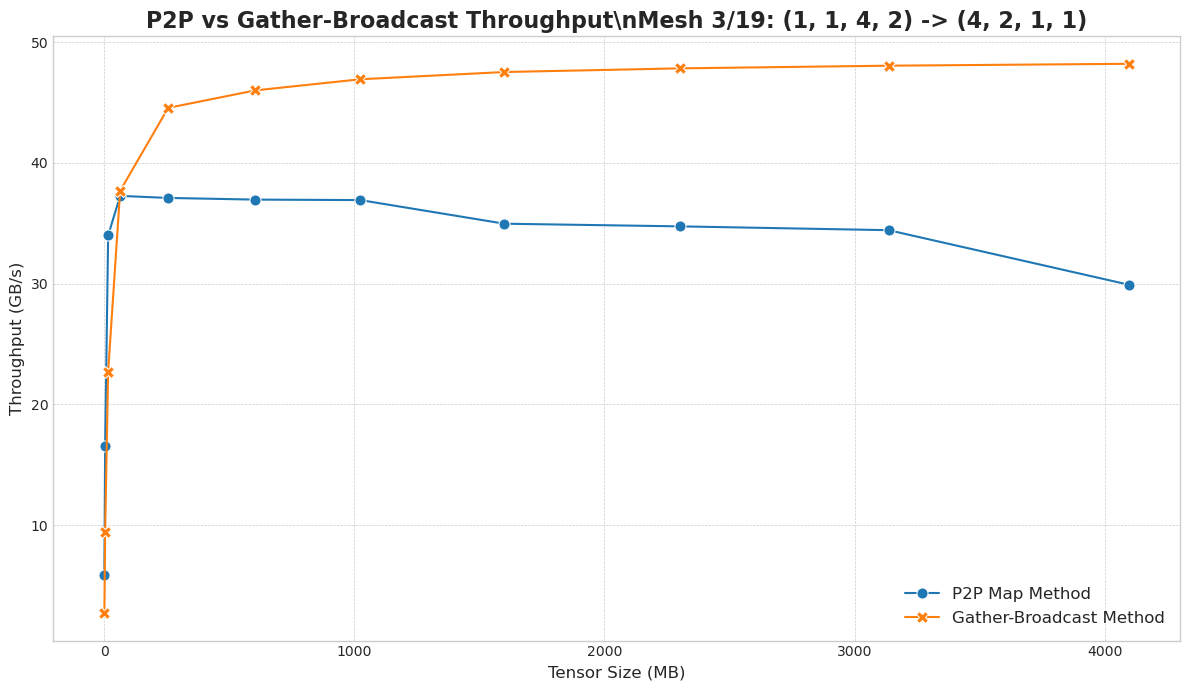

✅ Mesh组合 3 测试完成
Mesh组合 3/19 处理完成
\n================================================================================
测试第 4/19 个mesh组合:
源mesh: (1, 2, 1, 4) -> 目标mesh: (1, 4, 2, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.035977240840147716
Forward map: {0: {(0, 0): [8, 10, 12, 14]}, 1: {(0, 0): [8, 10, 12, 14]}, 2: {(0, 0): [8, 10, 12, 14]}, 3: {(0, 0): [8, 10, 12, 14]}, 4: {(0, 0): [9, 11, 13, 15]}, 5: {(0, 0): [9, 11, 13, 15]}, 6: {(0, 0): [9, 11, 13, 15]}, 7: {(0, 0): [9, 11, 13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))]}, 9: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))], (0, 2): [(6, (0, 0))], (0, 3): [(7, (0, 0))]}, 10: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))]}, 11: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))], (0, 2): [(6, (0, 0))], (0, 3): [(7, (0, 0))]}, 12: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))]}, 13: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))], (0, 2): [(6, (0, 0))], (0, 3): [(7, (0, 0))]}, 14: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))], (0, 2): [(2, (0, 0))], (0, 3): [(3, (0, 0))]}, 15: {(0, 

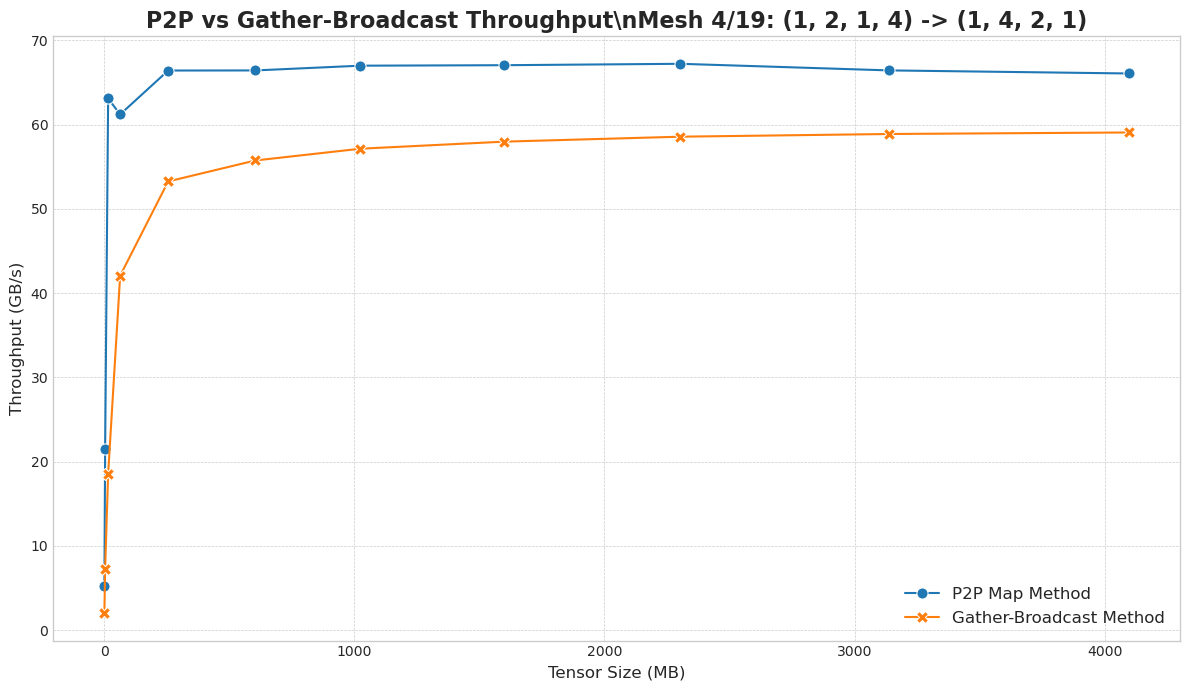

✅ Mesh组合 4 测试完成
Mesh组合 4/19 处理完成
\n================================================================================
测试第 5/19 个mesh组合:
源mesh: (1, 2, 2, 2) -> 目标mesh: (2, 1, 4, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.038549029319838155
Forward map: {0: {(0, 0): [8, 12], (1, 0): [9, 13]}, 1: {(0, 0): [8, 12], (1, 0): [9, 13]}, 6: {(0, 0): [10, 14], (1, 0): [11, 15]}, 7: {(0, 0): [10, 14], (1, 0): [11, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9: {(0, 0): [(0, (1, 0))], (0, 1): [(1, (1, 0))]}, 10: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}, 11: {(0, 0): [(6, (1, 0))], (0, 1): [(7, (1, 0))]}, 12: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 13: {(0, 0): [(0, (1, 0))], (0, 1): [(1, (1, 0))]}, 14: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}, 15: {(0, 0): [(6, (1, 0))], (0, 1): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.03854973181994865
Forward map: {0: {(0, 0): [8, 12], (1, 0): [9, 13]}, 1: {(0, 0): [8, 12], (1, 0): [9, 13]}, 6: {(0, 0): [10, 14], (1, 0): [11, 15]}, 7: {(0, 0): [10, 14], (1, 0): [11, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9: {(0, 0): [(0, (1, 0))], (0, 1): [(1,

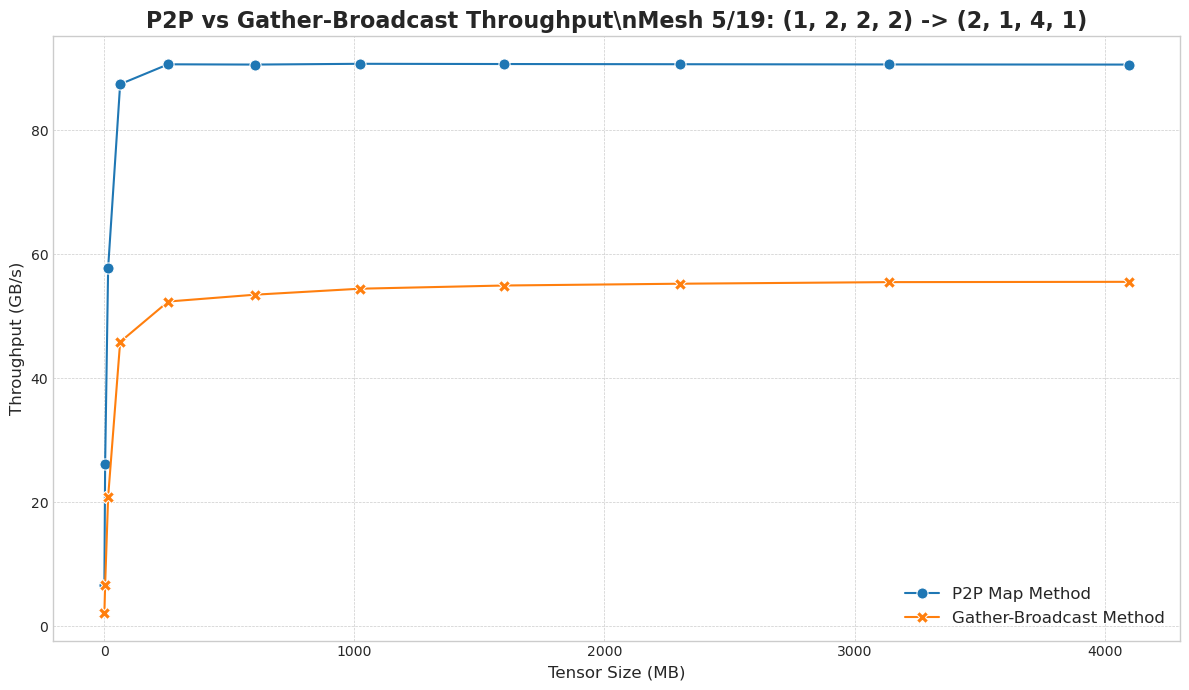

✅ Mesh组合 5 测试完成
Mesh组合 5/19 处理完成
\n================================================================================
测试第 6/19 个mesh组合:
源mesh: (1, 2, 4, 1) -> 目标mesh: (8, 1, 1, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03219316914008232
Forward map: {0: {(0, 0): [8, 12]}, 4: {(0, 0): [8, 12]}, 1: {(0, 0): [9, 13]}, 5: {(0, 0): [9, 13]}, 2: {(0, 0): [10, 14]}, 6: {(0, 0): [10, 14]}, 3: {(0, 0): [11, 15]}, 7: {(0, 0): [11, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(4, (0, 0))]}, 9: {(0, 0): [(1, (0, 0))], (1, 0): [(5, (0, 0))]}, 10: {(0, 0): [(2, (0, 0))], (1, 0): [(6, (0, 0))]}, 11: {(0, 0): [(3, (0, 0))], (1, 0): [(7, (0, 0))]}, 12: {(0, 0): [(0, (0, 0))], (1, 0): [(4, (0, 0))]}, 13: {(0, 0): [(1, (0, 0))], (1, 0): [(5, (0, 0))]}, 14: {(0, 0): [(2, (0, 0))], (1, 0): [(6, (0, 0))]}, 15: {(0, 0): [(3, (0, 0))], (1, 0): [(7, (0, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.032192580240080135
Forward map: {0: {(0, 0): [8, 12]}, 4: {(0, 0): [8, 12]}, 1: {(0, 0): [9, 13]}, 5: {(0, 0): [9, 13]}, 2: {(0, 0): [10, 14]}, 6: {(0, 0): [10, 14]}, 3: {(0, 0): [11, 15]}, 7: {(0, 0): [11, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(4, (0, 0))]},

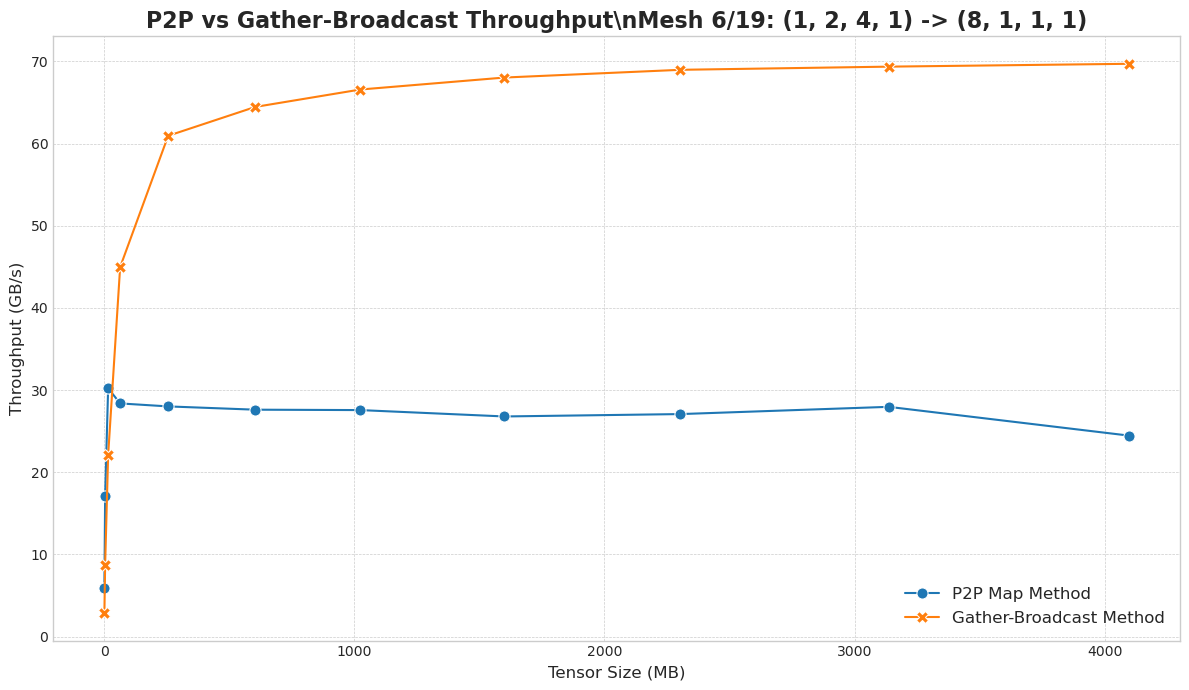

✅ Mesh组合 6 测试完成
Mesh组合 6/19 处理完成
\n================================================================================
测试第 7/19 个mesh组合:
源mesh: (1, 4, 1, 2) -> 目标mesh: (1, 1, 8, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03997519522003131
Forward map: {0: {(0, 0): [8], (1, 0): [9]}, 1: {(0, 0): [8], (1, 0): [9]}, 2: {(0, 0): [10], (1, 0): [11]}, 3: {(0, 0): [10], (1, 0): [11]}, 4: {(0, 0): [12], (1, 0): [13]}, 5: {(0, 0): [12], (1, 0): [13]}, 6: {(0, 0): [14], (1, 0): [15]}, 7: {(0, 0): [14], (1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (0, 1): [(1, (0, 0))]}, 9: {(0, 0): [(0, (1, 0))], (0, 1): [(1, (1, 0))]}, 10: {(0, 0): [(2, (0, 0))], (0, 1): [(3, (0, 0))]}, 11: {(0, 0): [(2, (1, 0))], (0, 1): [(3, (1, 0))]}, 12: {(0, 0): [(4, (0, 0))], (0, 1): [(5, (0, 0))]}, 13: {(0, 0): [(4, (1, 0))], (0, 1): [(5, (1, 0))]}, 14: {(0, 0): [(6, (0, 0))], (0, 1): [(7, (0, 0))]}, 15: {(0, 0): [(6, (1, 0))], (0, 1): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.039975095980043986
Forward map: {0: {(0, 0): [8], (1, 0): [9]}, 1: {(0, 0): [8], (1, 0): [9]}, 2: {(0, 0): [10], (1, 0): [11]}, 3: {(0, 0): [10], (1, 0): [11]}, 4: {(0, 0): [12], (1, 0): [13]}, 5: 

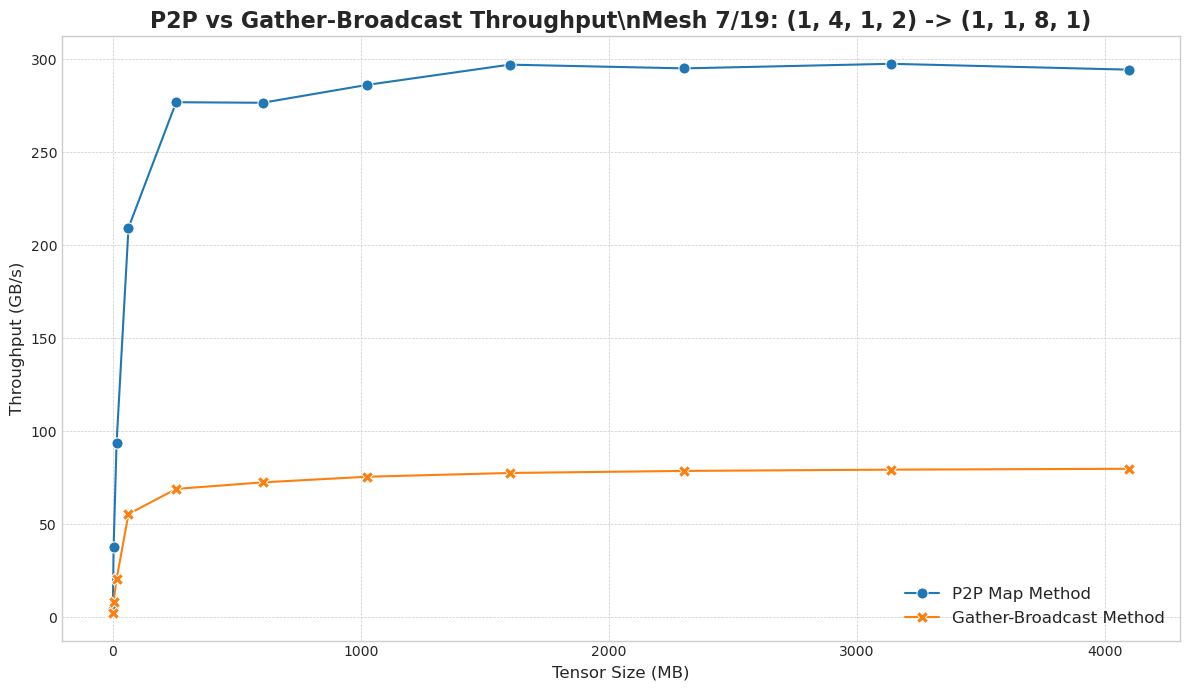

✅ Mesh组合 7 测试完成
Mesh组合 7/19 处理完成
\n================================================================================
测试第 8/19 个mesh组合:
源mesh: (1, 4, 2, 1) -> 目标mesh: (1, 8, 1, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03258596428000601
Forward map: {0: {(0, 0): [8, 10, 12, 14]}, 2: {(0, 0): [8, 10, 12, 14]}, 4: {(0, 0): [8, 10, 12, 14]}, 6: {(0, 0): [8, 10, 12, 14]}, 1: {(0, 0): [9, 11, 13, 15]}, 3: {(0, 0): [9, 11, 13, 15]}, 5: {(0, 0): [9, 11, 13, 15]}, 7: {(0, 0): [9, 11, 13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))], (2, 0): [(4, (0, 0))], (3, 0): [(6, (0, 0))]}, 9: {(0, 0): [(1, (0, 0))], (1, 0): [(3, (0, 0))], (2, 0): [(5, (0, 0))], (3, 0): [(7, (0, 0))]}, 10: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))], (2, 0): [(4, (0, 0))], (3, 0): [(6, (0, 0))]}, 11: {(0, 0): [(1, (0, 0))], (1, 0): [(3, (0, 0))], (2, 0): [(5, (0, 0))], (3, 0): [(7, (0, 0))]}, 12: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))], (2, 0): [(4, (0, 0))], (3, 0): [(6, (0, 0))]}, 13: {(0, 0): [(1, (0, 0))], (1, 0): [(3, (0, 0))], (2, 0): [(5, (0, 0))], (3, 0): [(7, (0, 0))]}, 14: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))], (2, 0): [(4, (0, 0))], (3, 0): [(6, (0, 0))]}, 15: {(0, 0

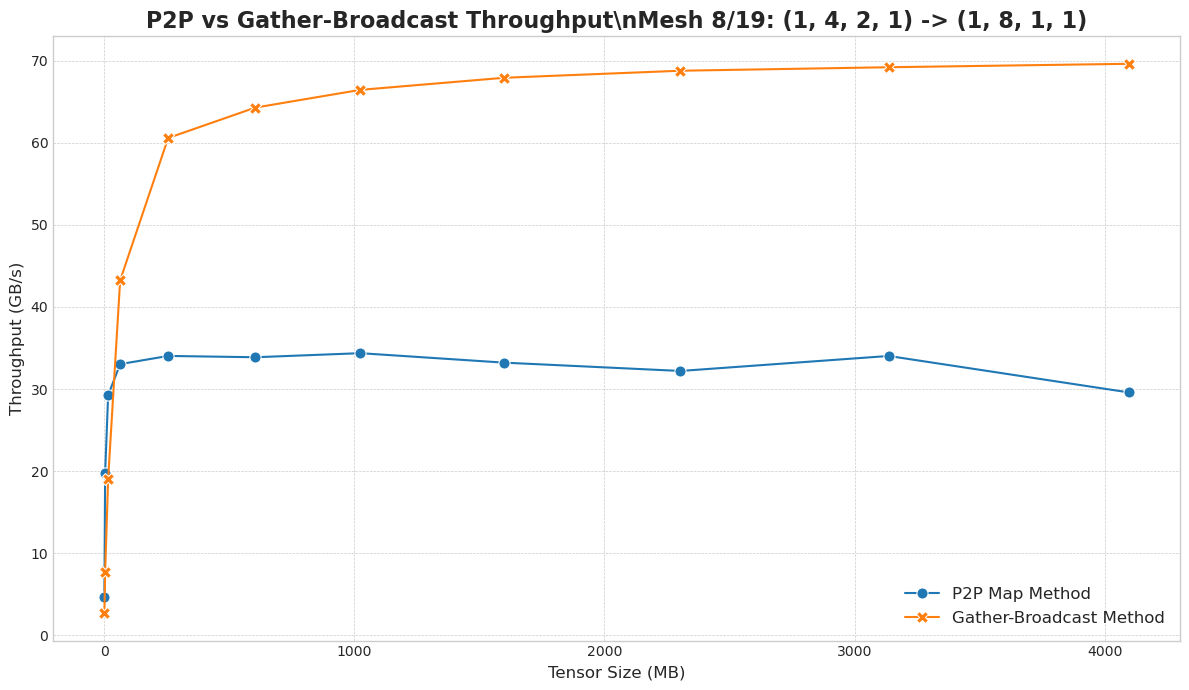

✅ Mesh组合 8 测试完成
Mesh组合 8/19 处理完成
\n================================================================================
测试第 9/19 个mesh组合:
源mesh: (1, 8, 1, 1) -> 目标mesh: (2, 2, 1, 2)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.02855341682006838
Forward map: {0: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 1: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 2: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 3: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 4: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 5: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 6: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}, 7: {(0, 0): [8, 10, 12, 14], (0, 1): [9, 11, 13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(1, (0, 0))], (2, 0): [(2, (0, 0))], (3, 0): [(3, (0, 0))], (4, 0): [(4, (0, 0))], (5, 0): [(5, (0, 0))], (6, 0): [(6, (0, 0))], (7, 0): [(7, (0, 0))]}, 9: {(0, 0): [(0, (0, 1))], (1, 0): [(1, (0, 1))], (2, 0): [(2, (0, 1))], (3, 0): [(3, (0, 1))], (4, 0): [(4, (0, 1))], (5, 0): [(5, (0, 1))], (6, 0): [(6, (0, 1))], (7, 0): [(7, (0, 1))]}, 10: {(0, 0): [(0, (0, 0))], (1, 0): [(1, (0, 0))], (2, 0): [(2, (0, 0))], (3, 0): [(3, (0, 0))], (4, 0): [(4, (0, 0)

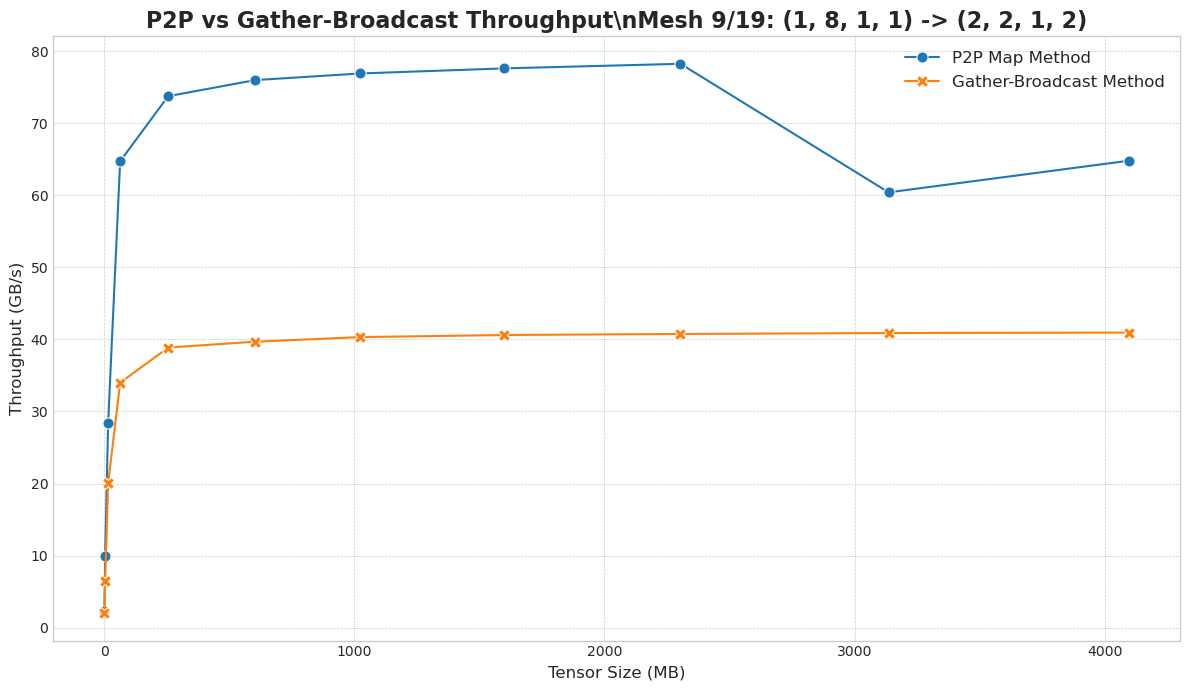

✅ Mesh组合 9 测试完成
Mesh组合 9/19 处理完成
\n================================================================================
测试第 10/19 个mesh组合:
源mesh: (2, 1, 1, 4) -> 目标mesh: (1, 1, 2, 4)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.034195456599991306
Forward map: {0: {(0, 0): [8]}, 1: {(0, 0): [9]}, 2: {(0, 0): [10]}, 3: {(0, 0): [11]}, 4: {(1, 0): [12]}, 5: {(1, 0): [13]}, 6: {(1, 0): [14]}, 7: {(1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(1, (0, 0))]}, 10: {(0, 0): [(2, (0, 0))]}, 11: {(0, 0): [(3, (0, 0))]}, 12: {(0, 0): [(4, (1, 0))]}, 13: {(0, 0): [(5, (1, 0))]}, 14: {(0, 0): [(6, (1, 0))]}, 15: {(0, 0): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.034195823780028146
Forward map: {0: {(0, 0): [8]}, 1: {(0, 0): [9]}, 2: {(0, 0): [10]}, 3: {(0, 0): [11]}, 4: {(1, 0): [12]}, 5: {(1, 0): [13]}, 6: {(1, 0): [14]}, 7: {(1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(1, (0, 0))]}, 10: {(0, 0): [(2, (0, 0))]}, 11: {(0, 0): [(3, (0, 0))]}, 12: {(0, 0): [(4, (1, 0))]}, 13: {(0, 0): [(5, (1, 0))]}, 14: {(0, 0): [(6, (1, 0))]}, 15: {(0, 0): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
  Benchmarking tenso

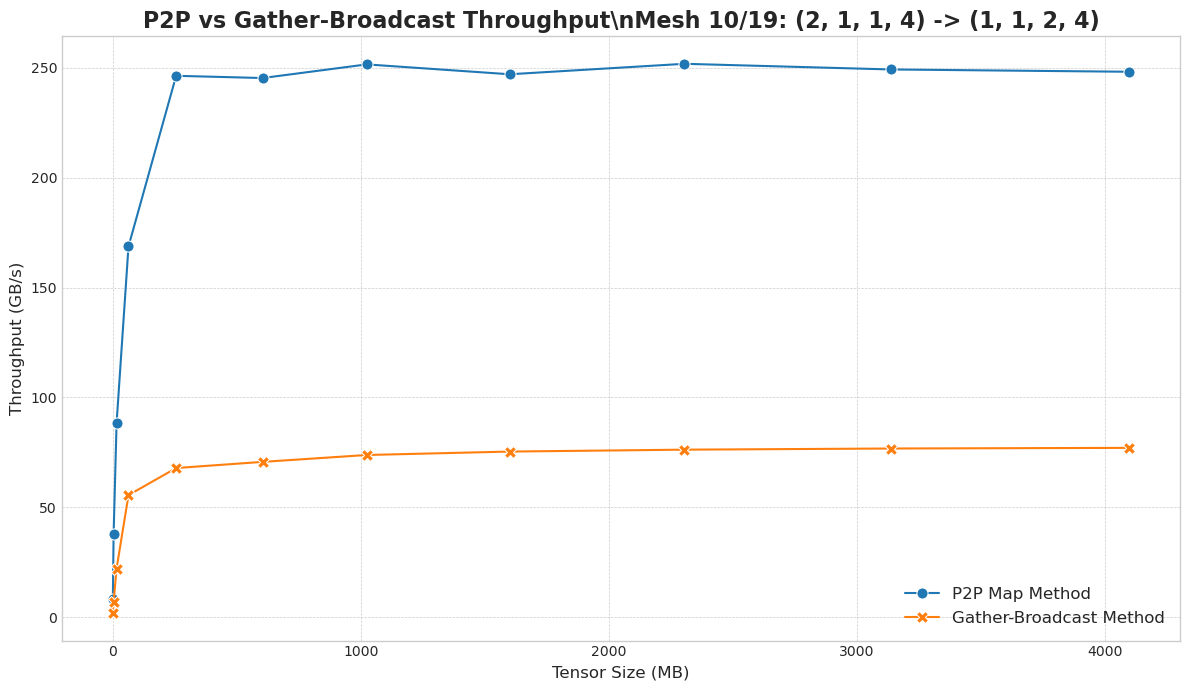

✅ Mesh组合 10 测试完成
Mesh组合 10/19 处理完成
\n================================================================================
测试第 11/19 个mesh组合:
源mesh: (2, 1, 2, 2) -> 目标mesh: (1, 2, 1, 4)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.03143120316002751
Forward map: {0: {(0, 0): [8], (0, 1): [9]}, 3: {(0, 0): [10], (0, 1): [11]}, 4: {(0, 0): [12], (0, 1): [13]}, 7: {(0, 0): [14], (0, 1): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(0, (0, 1))]}, 10: {(0, 0): [(3, (0, 0))]}, 11: {(0, 0): [(3, (0, 1))]}, 12: {(0, 0): [(4, (0, 0))]}, 13: {(0, 0): [(4, (0, 1))]}, 14: {(0, 0): [(7, (0, 0))]}, 15: {(0, 0): [(7, (0, 1))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.03143108341988409
Forward map: {0: {(0, 0): [8], (0, 1): [9]}, 3: {(0, 0): [10], (0, 1): [11]}, 4: {(0, 0): [12], (0, 1): [13]}, 7: {(0, 0): [14], (0, 1): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(0, (0, 1))]}, 10: {(0, 0): [(3, (0, 0))]}, 11: {(0, 0): [(3, (0, 1))]}, 12: {(0, 0): [(4, (0, 0))]}, 13: {(0, 0): [(4, (0, 1))]}, 14: {(0, 0): [(7, (0, 0))]}, 15: {(0, 0): [(7, (0, 1))]}}
  Benchmarking tensor shape: (512, 512)...
  Benchmarking tensor shape: (1024, 1024)...
  Benchmarking te

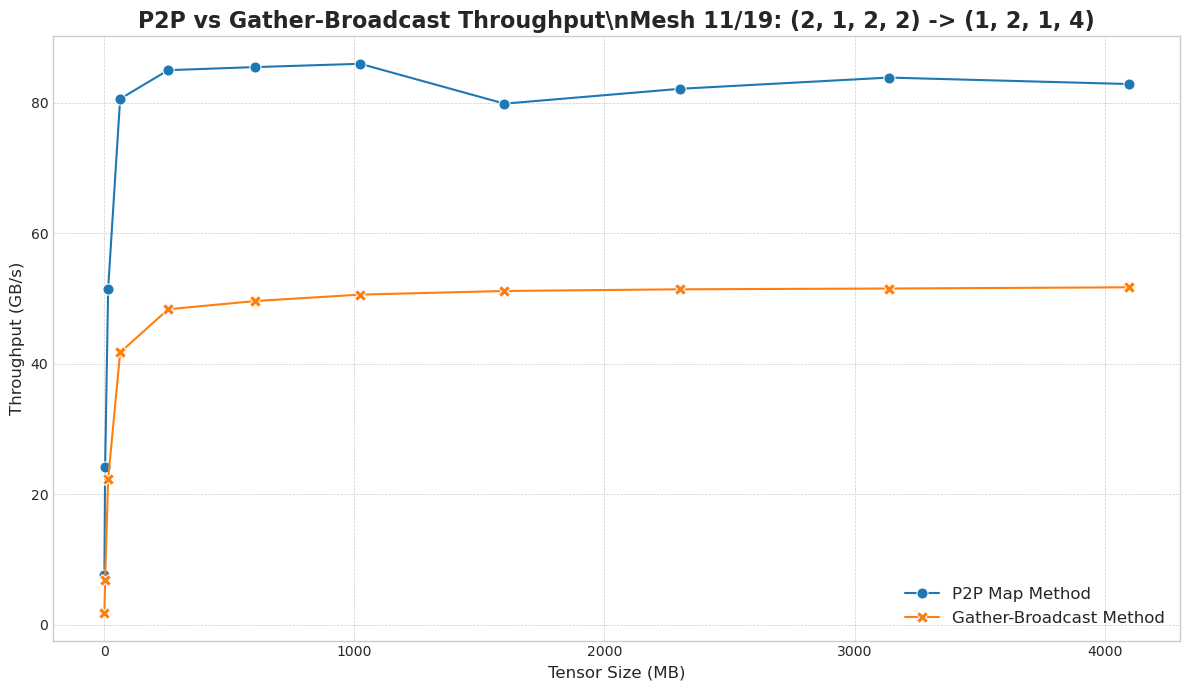

✅ Mesh组合 11 测试完成
Mesh组合 11/19 处理完成
\n================================================================================
测试第 12/19 个mesh组合:
源mesh: (2, 1, 4, 1) -> 目标mesh: (4, 1, 2, 1)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.02591364927997347
Forward map: {0: {(0, 0): [8]}, 1: {(1, 0): [9]}, 2: {(0, 0): [10]}, 3: {(1, 0): [11]}, 4: {(0, 0): [12]}, 5: {(1, 0): [13]}, 6: {(0, 0): [14]}, 7: {(1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(1, (1, 0))]}, 10: {(0, 0): [(2, (0, 0))]}, 11: {(0, 0): [(3, (1, 0))]}, 12: {(0, 0): [(4, (0, 0))]}, 13: {(0, 0): [(5, (1, 0))]}, 14: {(0, 0): [(6, (0, 0))]}, 15: {(0, 0): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.025913660759979393
Forward map: {0: {(0, 0): [8]}, 1: {(1, 0): [9]}, 2: {(0, 0): [10]}, 3: {(1, 0): [11]}, 4: {(0, 0): [12]}, 5: {(1, 0): [13]}, 6: {(0, 0): [14]}, 7: {(1, 0): [15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))]}, 9: {(0, 0): [(1, (1, 0))]}, 10: {(0, 0): [(2, (0, 0))]}, 11: {(0, 0): [(3, (1, 0))]}, 12: {(0, 0): [(4, (0, 0))]}, 13: {(0, 0): [(5, (1, 0))]}, 14: {(0, 0): [(6, (0, 0))]}, 15: {(0, 0): [(7, (1, 0))]}}
  Benchmarking tensor shape: (512, 512)...
  Benchmarking tensor

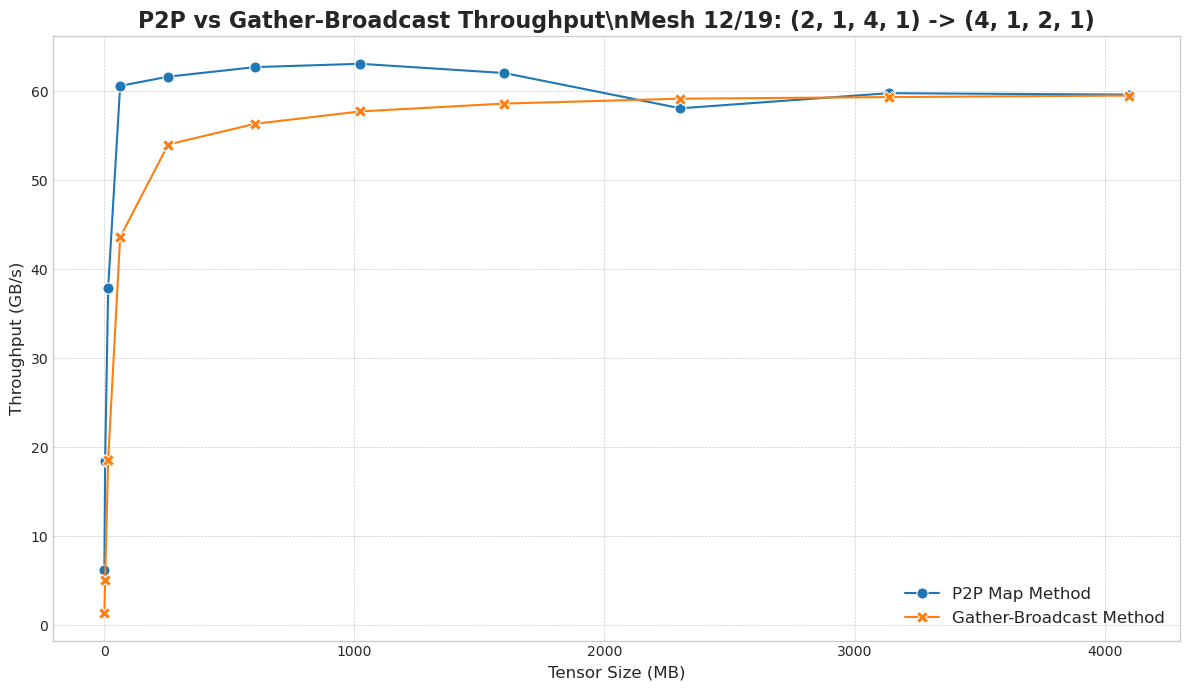

✅ Mesh组合 12 测试完成
Mesh组合 12/19 处理完成
\n================================================================================
测试第 13/19 个mesh组合:
源mesh: (2, 2, 1, 2) -> 目标mesh: (1, 4, 1, 2)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


/root/rl_comm/.pixi/envs/dev/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:4631: UserWarning: No device id is provided via `init_process_group` or `barrier `. Using the current device set by the user. 
  warnings.warn(  # warn only once


get_p2p_map time: 0.04011409283993998
Forward map: {0: {(0, 0): [8, 10]}, 2: {(0, 0): [8, 10]}, 1: {(0, 0): [9, 11]}, 3: {(0, 0): [9, 11]}, 4: {(0, 0): [12, 14]}, 6: {(0, 0): [12, 14]}, 5: {(0, 0): [13, 15]}, 7: {(0, 0): [13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))]}, 9: {(0, 0): [(1, (0, 0))], (1, 0): [(3, (0, 0))]}, 10: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))]}, 11: {(0, 0): [(1, (0, 0))], (1, 0): [(3, (0, 0))]}, 12: {(0, 0): [(4, (0, 0))], (1, 0): [(6, (0, 0))]}, 13: {(0, 0): [(5, (0, 0))], (1, 0): [(7, (0, 0))]}, 14: {(0, 0): [(4, (0, 0))], (1, 0): [(6, (0, 0))]}, 15: {(0, 0): [(5, (0, 0))], (1, 0): [(7, (0, 0))]}}
  Benchmarking tensor shape: (512, 512)...
get_p2p_map time: 0.04011375062022125
Forward map: {0: {(0, 0): [8, 10]}, 2: {(0, 0): [8, 10]}, 1: {(0, 0): [9, 11]}, 3: {(0, 0): [9, 11]}, 4: {(0, 0): [12, 14]}, 6: {(0, 0): [12, 14]}, 5: {(0, 0): [13, 15]}, 7: {(0, 0): [13, 15]}}
Reverse map: {8: {(0, 0): [(0, (0, 0))], (1, 0): [(2, (0, 0))]}, 

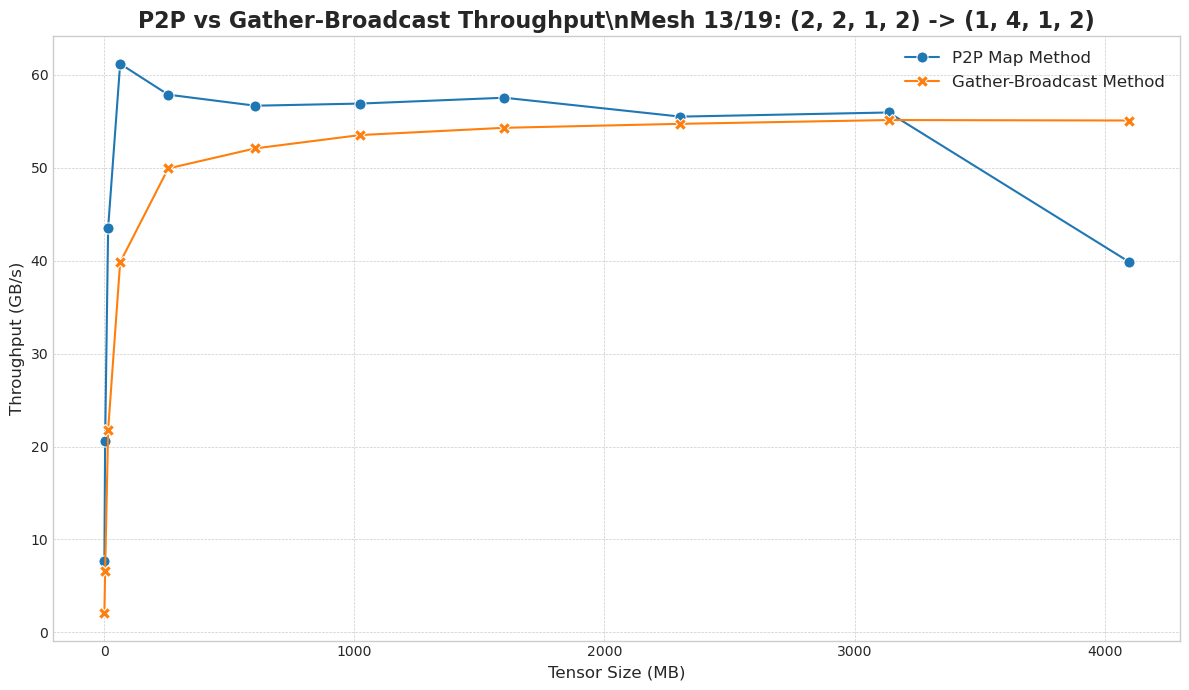

✅ Mesh组合 13 测试完成
Mesh组合 13/19 处理完成
\n================================================================================
测试第 14/19 个mesh组合:
源mesh: (2, 2, 2, 1) -> 目标mesh: (1, 1, 4, 2)
源mesh大小: 8卡, 目标mesh大小: 8卡, 总计: 16卡


[rank10]:[E718 07:28:58.171482522 ProcessGroupNCCL.cpp:632] [Rank 10] Watchdog caught collective operation timeout: WorkNCCL(SeqNum=20971, OpType=ALLREDUCE, NumelIn=1, NumelOut=1, Timeout(ms)=600000) ran for 600025 milliseconds before timing out.
[rank10]:[E718 07:28:58.171556151 ProcessGroupNCCL.cpp:2271] [PG ID 0 PG GUID 0(default_pg) Rank 10]  failure detected by watchdog at work sequence id: 20971 PG status: last enqueued work: 20971, last completed work: 20970
[rank10]:[E718 07:28:58.171562524 ProcessGroupNCCL.cpp:670] Stack trace of the failed collective not found, potentially because FlightRecorder is disabled. You can enable it by setting TORCH_NCCL_TRACE_BUFFER_SIZE to a non-zero value.
[rank10]:[E718 07:28:58.171594584 ProcessGroupNCCL.cpp:2106] [PG ID 0 PG GUID 0(default_pg) Rank 10] First PG on this rank to signal dumping.
[rank0]:[E718 07:28:58.713568770 ProcessGroupNCCL.cpp:1685] [PG ID 0 PG GUID 0(default_pg) Rank 0] Observed flight recorder dump signal from another rank

In [ ]:
# 为所有mesh组合运行benchmark并生成图片
print("开始批量测试所有mesh组合...")
print(f"总共有 {len(mesh_combinations)} 个mesh组合需要测试")

all_results = {}  # 存储所有mesh组合的结果

for mesh_idx, (source_mesh_shape, target_mesh_shape) in enumerate(mesh_combinations):
    print(f"\\n{'='*80}")
    print(f"测试第 {mesh_idx + 1}/{len(mesh_combinations)} 个mesh组合:")
    print(f"源mesh: {source_mesh_shape} -> 目标mesh: {target_mesh_shape}")
    print(f"{'='*80}")
    
    # 设置当前mesh
    source_world_size = math.prod(source_mesh_shape)
    target_world_size = math.prod(target_mesh_shape)
    
    print(f"源mesh大小: {source_world_size}卡, 目标mesh大小: {target_world_size}卡, 总计: {source_world_size + target_world_size}卡")
    
    # 创建mesh
    current_source_mesh = DeviceMesh(device, torch.arange(source_world_size).view(source_mesh_shape))
    current_target_mesh = DeviceMesh(
        device, torch.arange(source_world_size, source_world_size + target_world_size).view(target_mesh_shape)
    )
    
    # 为当前mesh运行benchmark
    current_results = []
    if device == "cuda":
        torch.cuda.synchronize(device=f"cuda:{local_rank}")
    dist.barrier(device_ids=[local_rank])
        
    start_time = time.perf_counter()
    forward_map, reverse_map, source_num_slicers, target_num_slicers = get_p2p_map(
        current_source_mesh,
        source_specs,
        current_target_mesh,
        target_specs,
        rank,
        source_world_size,
        target_world_size,
        device,
    )
    map_time = (time.perf_counter() - start_time) / profile_iter
    print(f"get_p2p_map time: {map_time}")
    print(f"Forward map: {forward_map}")
    print(f"Reverse map: {reverse_map}")

    for shape in tensor_shapes:
        print(f"  Benchmarking tensor shape: {shape}...")        
        torch.manual_seed(0)
        origin_tensor = torch.randn(shape, device=device)
        tensor_size_bytes = origin_tensor.nelement() * origin_tensor.element_size()
        tensor_size_gb = tensor_size_bytes / (1024**3)

        is_in_source = rank < source_world_size

        source_dist_tensor = None
        if is_in_source:
            source_dist_tensor = distribute_tensor(origin_tensor, current_source_mesh, source_specs)

        target_local_shape = get_shard_tensor_shape(
            origin_tensor.shape, current_target_mesh, target_specs
        )
        p2p_result = None
        # P2P方法benchmark
        dist.barrier(device_ids=[local_rank])
        for _ in range(warmup_iter):
            p2p_result = p2p_communicate(
                rank,
                forward_map,
                reverse_map,
                source_dist_tensor,
                source_num_slicers,
                target_num_slicers,
                target_local_shape,
                device=device,
                dtype=torch.float32,
            )
        if device == "cuda":
            torch.cuda.synchronize(device=f"cuda:{local_rank}")
        dist.barrier(device_ids=[local_rank])
        
        start_time = time.perf_counter()
        for _ in range(profile_iter):
            p2p_communicate(
                rank,
                forward_map,
                reverse_map,
                source_dist_tensor,
                source_num_slicers,
                target_num_slicers,
                target_local_shape,
                device=device,
                dtype=torch.float32,
            )
        if device == "cuda":
            torch.cuda.synchronize(device=f"cuda:{local_rank}")
        dist.barrier(device_ids=[local_rank])
        p2p_time = (time.perf_counter() - start_time) / profile_iter

        bc_result = None
        # Gather-Broadcast方法benchmark
        dist.barrier(device_ids=[local_rank])
        for _ in range(warmup_iter):
            bc_result = gather_broadcast_communicate(
                rank,
                current_target_mesh,
                target_specs,
                source_dist_tensor,
                origin_tensor,
                source_world_size,
                device,
            )
        if p2p_result is not None and bc_result is not None:
            assert torch.allclose(p2p_result, bc_result.to_local()), "P2P和Gather-Broadcast方法的结果不一致！"
        if device == "cuda":
            torch.cuda.synchronize(device=f"cuda:{local_rank}")
        dist.barrier(device_ids=[local_rank])
        
        start_time = time.perf_counter()
        for _ in range(profile_iter):
            gather_broadcast_communicate(
                rank,
                current_target_mesh,
                target_specs,
                source_dist_tensor,
                origin_tensor,
                source_world_size,
                device,
            )
        if device == "cuda":
            torch.cuda.synchronize(device=f"cuda:{local_rank}")
        dist.barrier(device_ids=[local_rank])
        baseline_time = (time.perf_counter() - start_time) / profile_iter

        if rank == 0:
            p2p_throughput = tensor_size_gb / p2p_time
            baseline_throughput = tensor_size_gb / baseline_time
            current_results.append({
                "tensor_shape": str(shape),
                "tensor_size_mb": tensor_size_bytes / (1024**2),
                "p2p_throughput_gb_s": p2p_throughput,
                "baseline_throughput_gb_s": baseline_throughput,
            })
    
    # 为当前mesh生成图片
    if rank == 0 and current_results:
        df = pd.DataFrame(current_results)
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(12, 7))

        sns.lineplot(
            data=df,
            x="tensor_size_mb",
            y="p2p_throughput_gb_s",
            marker="o",
            markersize=8,
            label="P2P Map Method",
            ax=ax,
        )
        sns.lineplot(
            data=df,
            x="tensor_size_mb",
            y="baseline_throughput_gb_s",
            marker="X",
            markersize=8,
            label="Gather-Broadcast Method",
            ax=ax,
        )

        ax.set_title(f"P2P vs Gather-Broadcast Throughput\\nMesh {mesh_idx+1}/{len(mesh_combinations)}: {source_mesh_shape} -> {target_mesh_shape}", fontsize=16, weight="bold")
        ax.set_xlabel("Tensor Size (MB)", fontsize=12)
        ax.set_ylabel("Throughput (GB/s)", fontsize=12)
        ax.legend(fontsize=12)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

        plt.tight_layout()
        
        # 生成文件名
        mesh_filename = f"mesh_{mesh_idx+1:02d}_{source_mesh_shape}_{target_mesh_shape}".replace(" ", "").replace("(", "").replace(")", "").replace(",", "_")
        fig_path = f"/root/rl_comm/bench/throughput_benchmark_{mesh_filename}.png"
        fig.savefig(fig_path, dpi=300)
        print(f"✅ 图片已保存: {fig_path}")
        
        # 显示图片
        plt.show()
        plt.close()
        
        # 保存结果
        all_results[f"mesh_{mesh_idx+1}_{source_mesh_shape}_{target_mesh_shape}"] = current_results
        
        print(f"✅ Mesh组合 {mesh_idx+1} 测试完成")
    
    print(f"Mesh组合 {mesh_idx+1}/{len(mesh_combinations)} 处理完成")

if rank == 0:
    print(f"\\n{'='*80}")
    print("所有mesh组合测试完成！")
    print(f"总共测试了 {len(mesh_combinations)} 个mesh组合")
    print(f"生成了 {len(all_results)} 个性能图表")
    print("所有图片保存在: /root/rl_comm/bench/")
    print(f"{'='*80}")

In [4]:
dist.destroy_process_group()